In [ ]:
import os
import sys
sys.path.append(os.path.dirname(os.path.dirname(__file__)))
from configs.config import * # directories + constants

import copy
import joblib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import nibabel as nib
import numpy as np
import os
import re
import rsatoolbox as rsa
import seaborn as sns
import sys
import warnings
from collections import defaultdict
from glob import glob

from nilearn import plotting
from nilearn.image import get_data, math_img, new_img_like, threshold_img
from nilearn.regions import connected_regions


# from utils.load_cfg import load_config_instance
from utils.load_cfg import load_MRI_config_instance
from utils.compile import compile_SL_rdms_files
from utils.subj import * 



# Functions

In [ ]:
import numpy as np
import nibabel as nib
from scipy.ndimage import label

def RDMcolormapObject(direction=1):
    cs = ['blue', 'turquoise', 'gray', 'red', 'yellow'] if direction else ['yellow', 'red', 'gray', 'turquoise', 'blue']
    return mcolors.LinearSegmentedColormap.from_list("", cs)

def plot_brainSlices(plot_img, cmap, title='', threshold = 1e-6):
 
    fig = plt.figure(figsize=(12, 3))
    plotting.plot_stat_map(
        plot_img, 
        colorbar=True, 
        threshold=threshold,
        cut_coords=[-30, -20, 0, 20, 40, 60],
        display_mode='z', 
        draw_cross=False, 
        figure=fig,
        title=title, 
        cmap=cmap,
        black_bg=False, 
        annotate=False
    )
    plt.show()

cmap = RDMcolormapObject()

def _get_data_mask_and_thres(config_class_name, subjectID, model, thres):
    cfg = load_MRI_config_instance(config_class_name, subjectID)
    cfg.modelType = model
    
    RDM_brain = joblib.load(cfg.get_outFile_names()['RDM_brain_fullBrain'])
    mask = nib.load(cfg.maskFile)

    RDM_brain_nan = copy.deepcopy(RDM_brain)
    RDM_brain_nan[RDM_brain_nan == 0] = np.nan
    mean_nan_img = new_img_like(mask, RDM_brain)

    threshold = np.nanpercentile(RDM_brain_nan, thres)

    thres_data = np.zeros(mask.shape)
    thres_data[RDM_brain > threshold] = 1

    return RDM_brain, mean_nan_img, mask, threshold, thres_data


def plot_all(all_subjects, config_class_name, model, thres= 95):

    # load data
    RDM_brain_list = []

    for subjectID in all_subjects:

        mean_nan_img, _, threshold, _ = _get_data_mask_and_thres(config_class_name, subjectID, model, thres)        

        #%% 4) --- plot mean over subjects but omit zeros (NaN)
        plot_brainSlices(mean_nan_img, cmap = 'viridis', title=f'{model} results subject: {subjectID}', threshold = threshold)
        

def plot_mean(all_subjects, config_class_name, model, thres= 95, plotList = [1], save = False, nii_filename=None):

    all_thres_data = [] 
    for subjectID in all_subjects:
        _, mask, _, thres_data = _get_data_mask_and_thres(config_class_name, subjectID, model, thres)   
        all_thres_data.append(thres_data)

    sum_threshold_mask_img = new_img_like(mask, np.sum(np.array(all_thres_data), axis=0))

    if save:
        outDir = '/home/reabt/experiments/ncc/MRI/data/rsa'
        if nii_filename == None:
            nii_filename = os.path.join(outDir, f'sum_threshold_mask_img__{model}__{config_class_name}__thres_{thres}__{len(all_subjects)}_subj.nii')
        nib.save(sum_threshold_mask_img, nii_filename)

    vmin = 0
    vmax = len(all_subjects)

    # --- for plotting:
    # Define your discrete color levels
    levels = np.arange(vmin, vmax + 2)  # one more than vmax for bins
    n_colors = len(levels) - 1

    # Create a discrete colormap using viridis
    base_cmap = plt.get_cmap('viridis')
    colors = base_cmap(np.linspace(0, 1, n_colors))
    cmap = ListedColormap(colors)

    # Create a normalization object to define the boundaries
    norm = BoundaryNorm(boundaries=levels, ncolors=n_colors)

    title = f'{model} (config {config_class_name[-2 :]}): sum of threshold mask images over {len(all_subjects)} subjects with thres = {thres}'
    # Plot with custom colormap and norm
    if 1 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="z",
            cut_coords=15,
            title=title,
            cmap=cmap,
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 2 in plotList:
        display = plotting.plot_stat_map(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'viridis'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

    if 3 in plotList:
        display = plotting.plot_glass_brain(
            sum_threshold_mask_img,
            display_mode="ortho",
            title=title,
            cbar_tick_format = "%i",
            colorbar=True,
            vmin=vmin,
            vmax=vmax,
            cmap = 'viridis'
        )

        cbar = display._cbar
        cbar.set_ticks(np.arange(vmin, vmax + 1))
        cbar.set_ticklabels([str(i) for i in range(vmin, vmax + 1)])
        cbar.ax.tick_params(labelsize=12)

# show single subjects

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


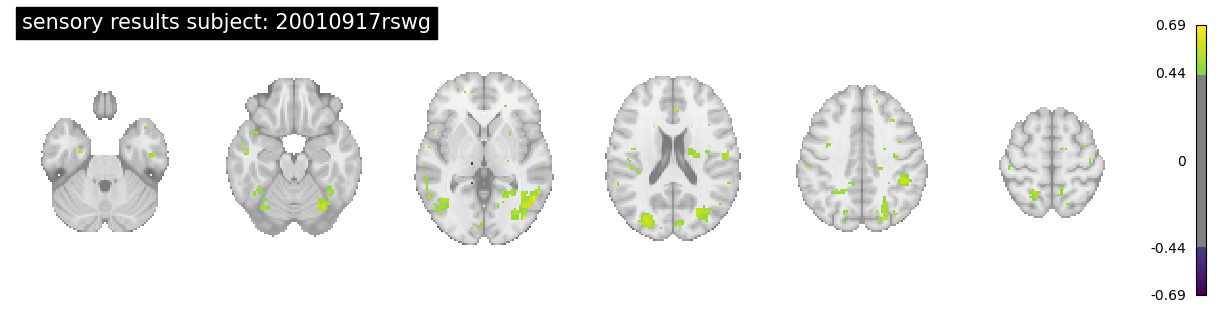

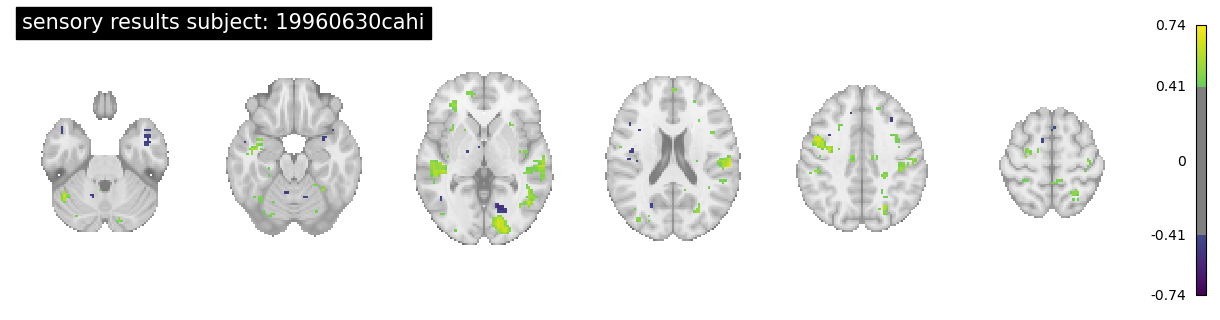

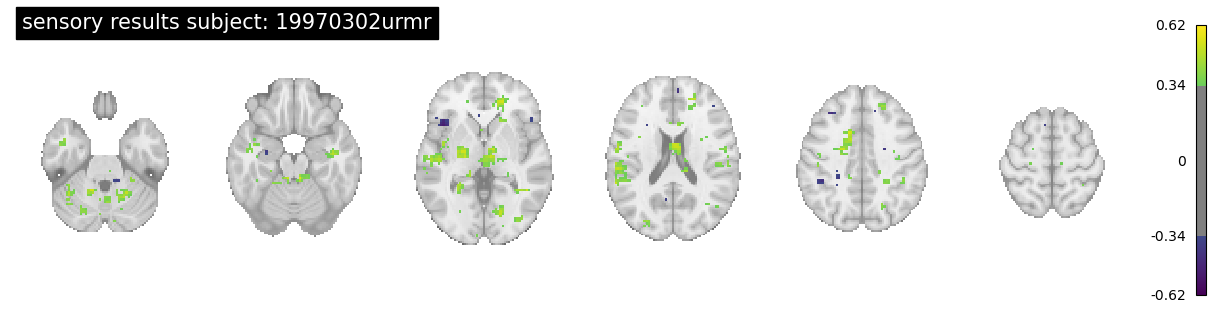

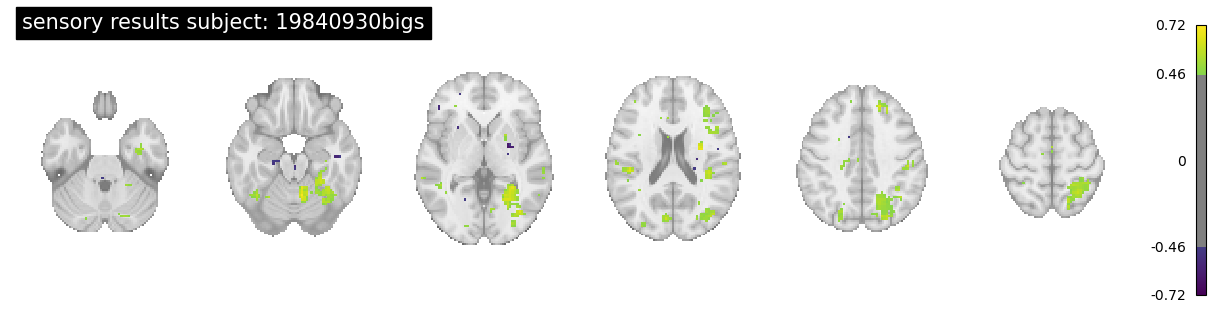

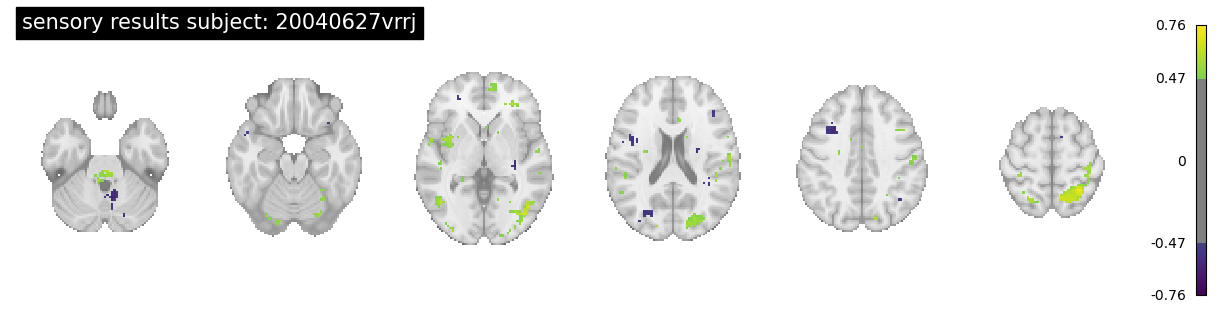

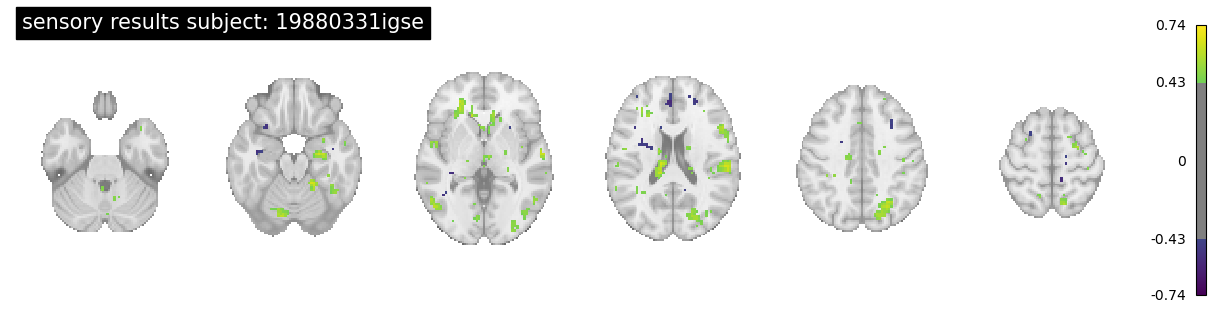

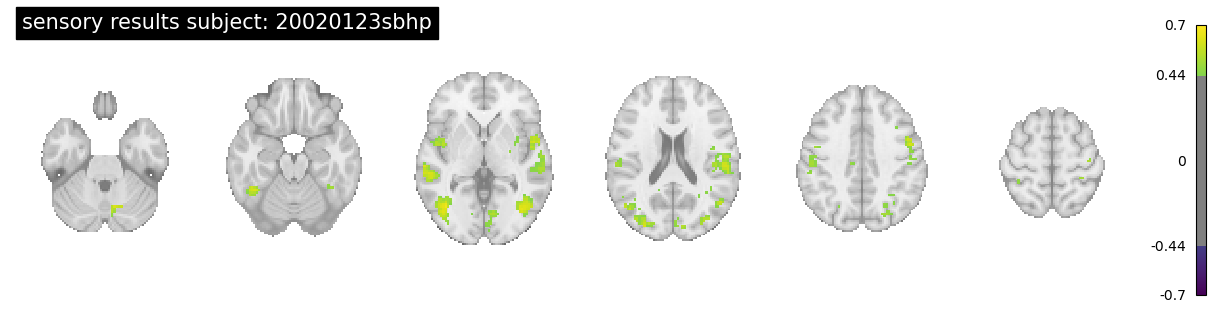

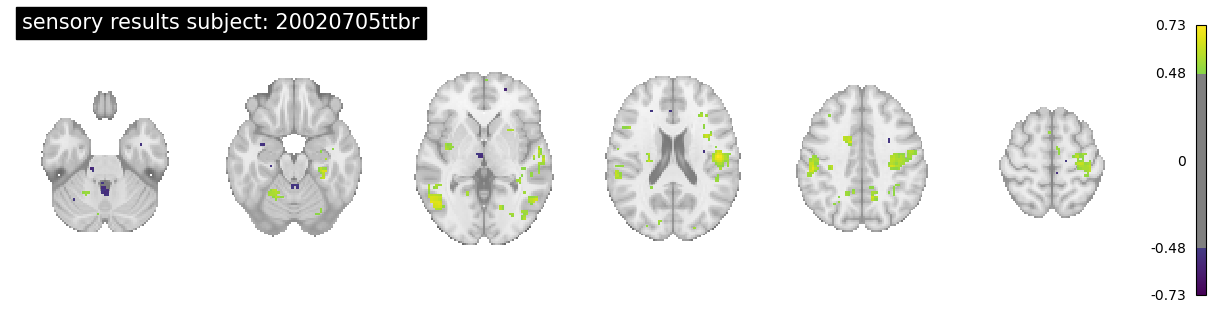

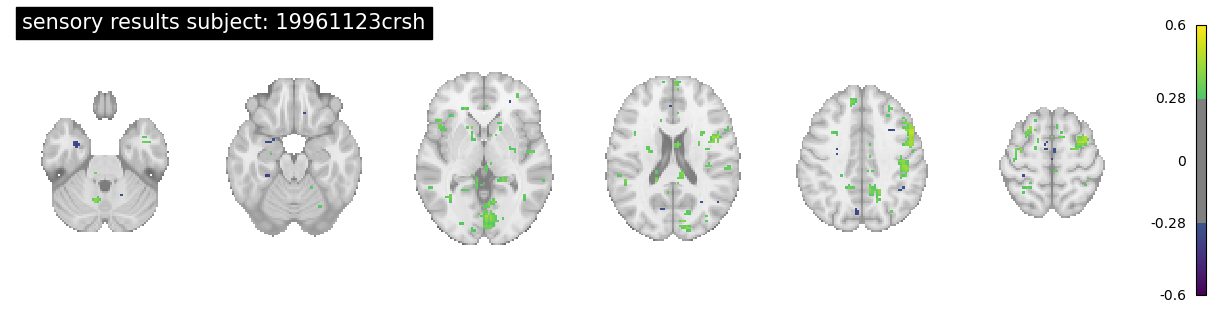

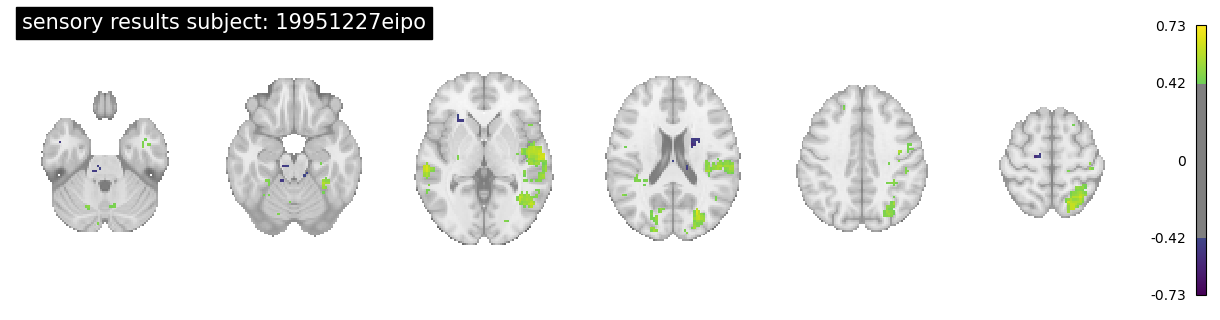

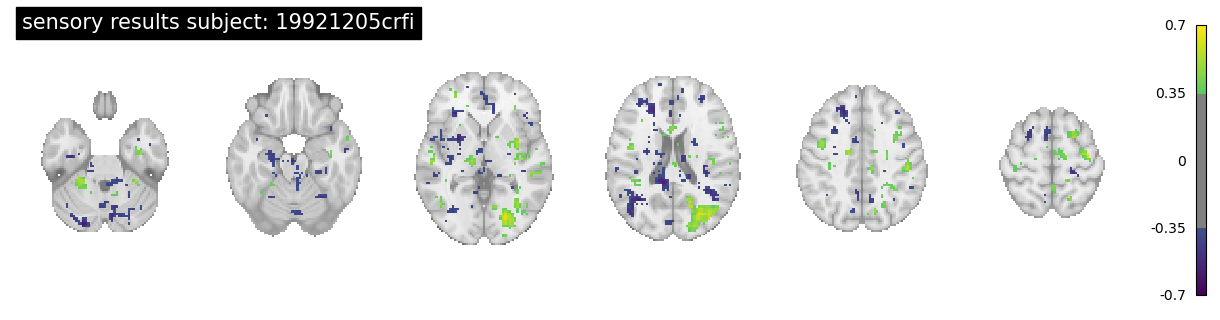

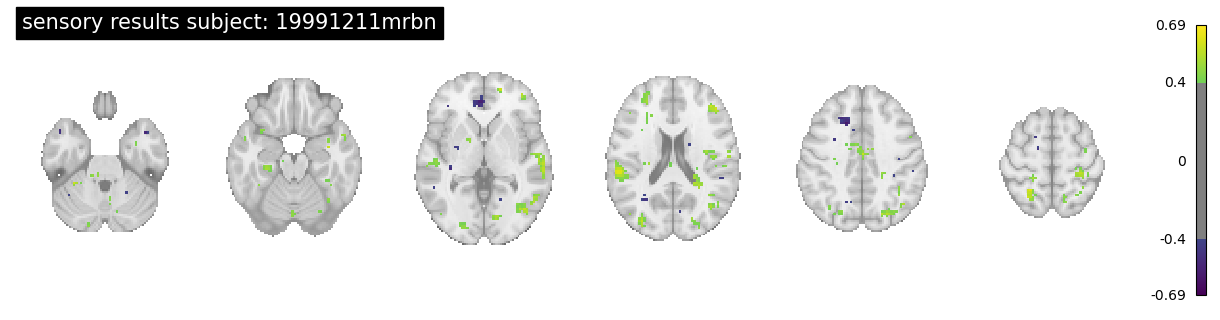

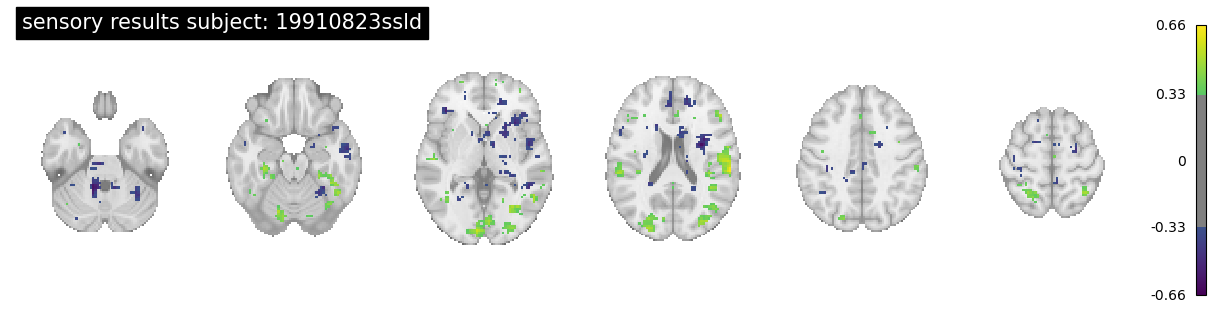

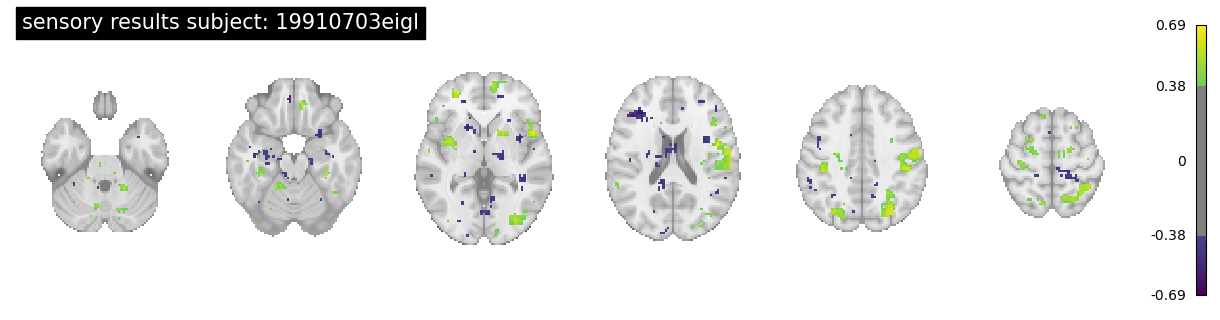

In [10]:
MRI_subjects = get_MRI_subjects()
all_subjects = [subj for subj in MRI_subjects if '19970218crpo' not in subj]

config_class_name = 'MRIconfig_C2'
model = 'sensory'
plot_all(all_subjects, config_class_name, model)


## single subject

In [ ]:
# load data
config_class_name = 'SensoryConfig_E4'
thres = 95


all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]
subjectID = all_subjects[0]

RDM_brain_list = []

# for subjectID in all_subjects:

cfg = load_MRI_config_instance(config_class_name, subjectID)
cfg.configure_paths()
outFiles = cfg.get_outFile_names()
RDM_brain = joblib.load(outFiles['RDM_brain_fullBrain'])

mask = nib.load(cfg.maskFile)
RDM_brain_nan = copy.deepcopy(RDM_brain)
RDM_brain_nan[RDM_brain_nan == 0] = np.nan
threshold = np.nanpercentile(RDM_brain_nan, thres)

mean_nan_img = new_img_like(mask, RDM_brain)

# easy way to filter data by threshold 
threshold_value_img = threshold_img(
    mean_nan_img, threshold= threshold, copy=True, copy_header=True
)

# binary mask including above average voxels = 1
threshold_mask = np.zeros(threshold_value_img.get_fdata().shape)
threshold_mask[threshold_value_img.get_fdata() > 0] = 1




## male vs. female

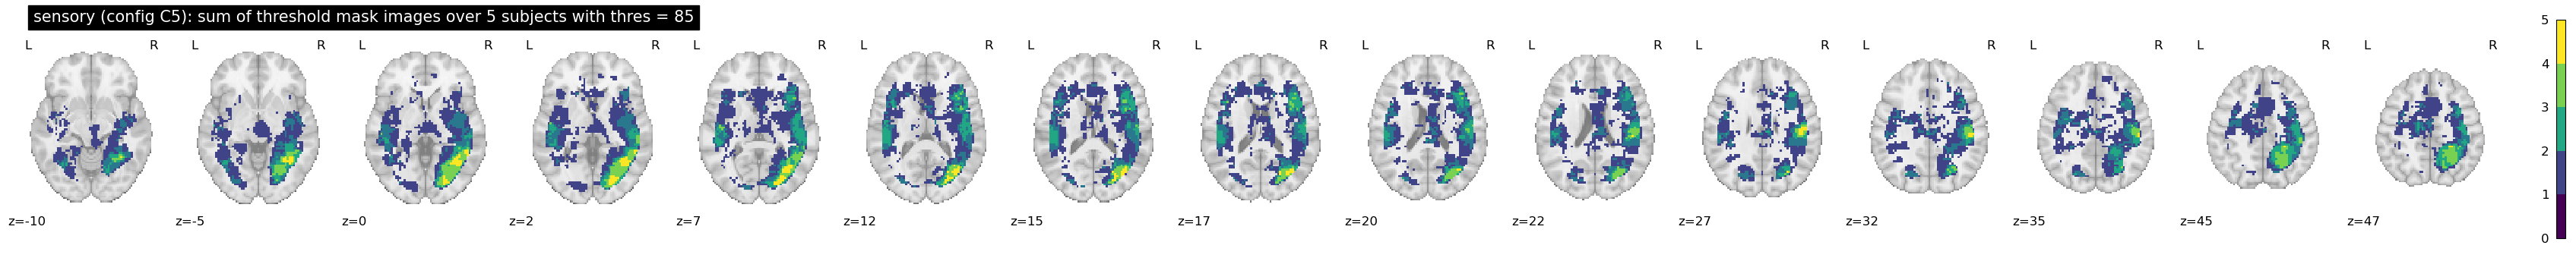

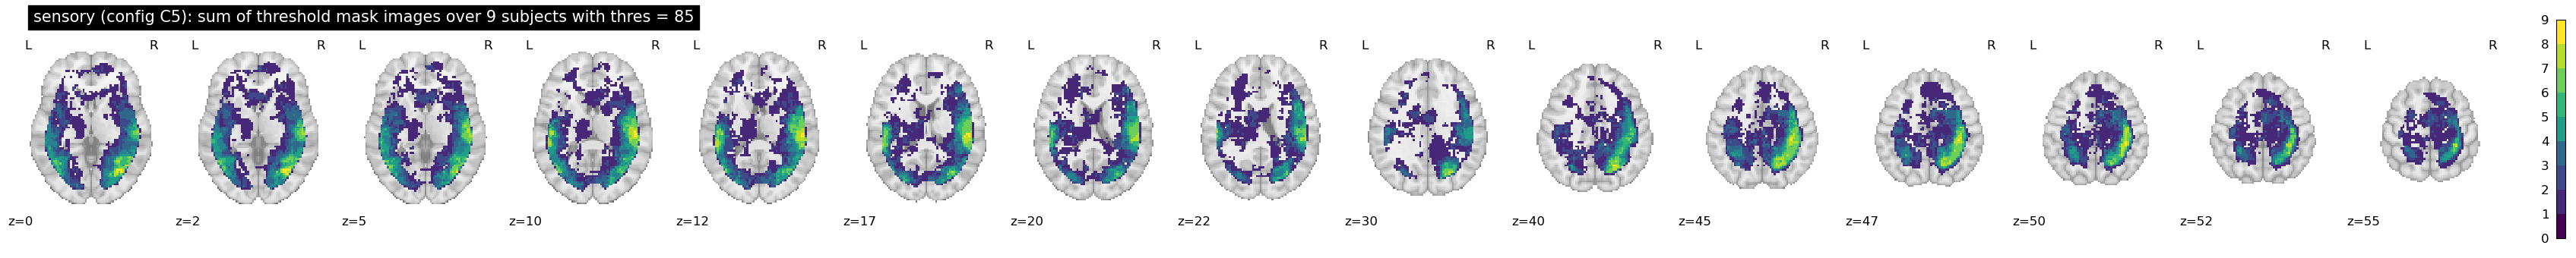

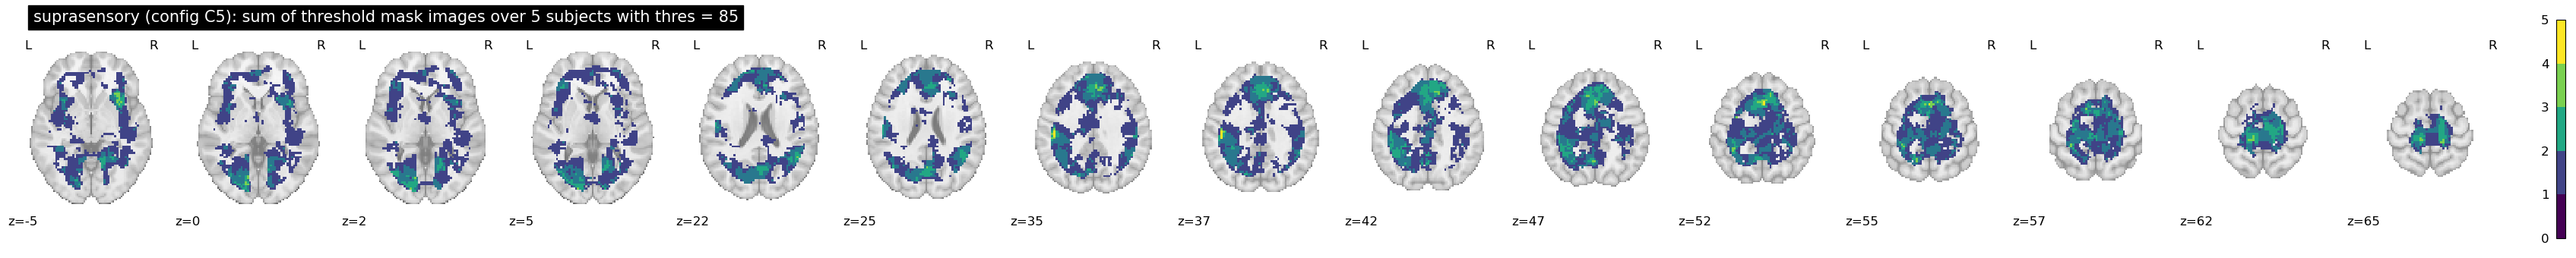

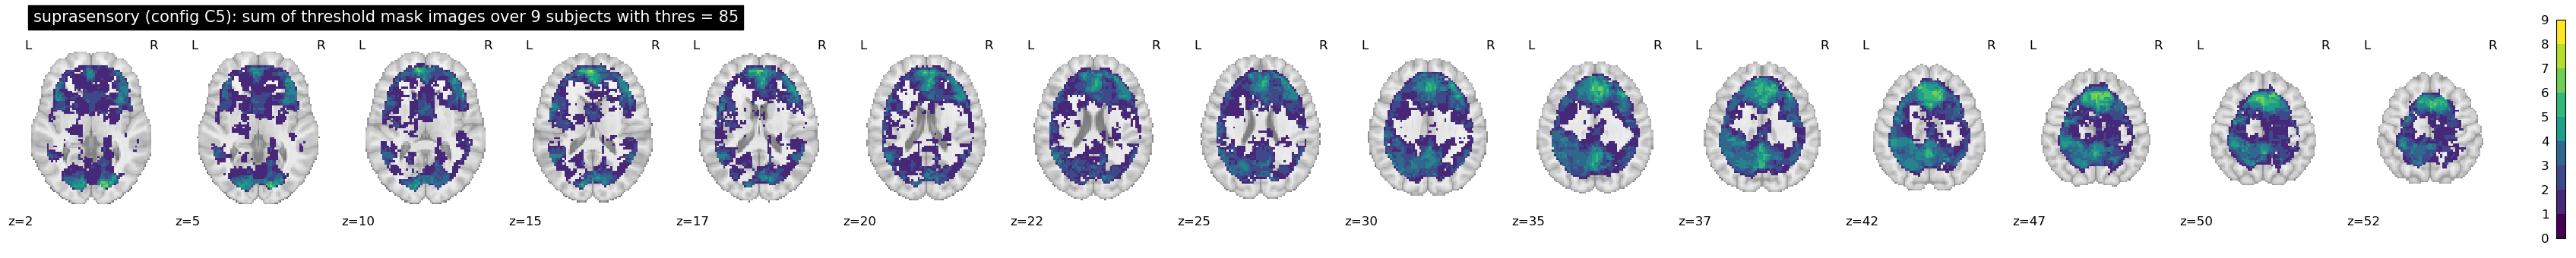

In [ ]:
male = ['19960630cahi', '19970302urmr', '19840930bigs', '19921205crfi', '19910823ssld', ]
female = ['20040627vrrj', '20010917rswg', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19991211mrbn', '19910703eigl']
thres = 85

plot_mean(male, 'MRIconfig_C5', 'sensory', thres=thres, save = False)
plot_mean(female, 'MRIconfig_C5', 'sensory', thres=thres, save = False)

plot_mean(male, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False)
plot_mean(female, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False)

In [ ]:
male = ['19960630cahi', '19970302urmr', '19840930bigs', '19921205crfi', '19910823ssld', ]
female = ['20040627vrrj', '20010917rswg', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19991211mrbn', '19910703eigl']
thres = 85

plot_mean(male, 'MRIconfig_C5', 'sensory', thres=thres, save = False)
plot_mean(female, 'MRIconfig_C5', 'sensory', thres=thres, save = False)

plot_mean(male, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False)
plot_mean(female, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False)

In [ ]:
male = ['19960630cahi', '19970302urmr', '19840930bigs', '19921205crfi', '19910823ssld', ]
female = ['20040627vrrj', '20010917rswg', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19991211mrbn', '19910703eigl']
thres = 85

plot_all(male, 'MRIconfig_C2', 'sensory')

# all subjects, sum of threshold masks

## 14 subjects

Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


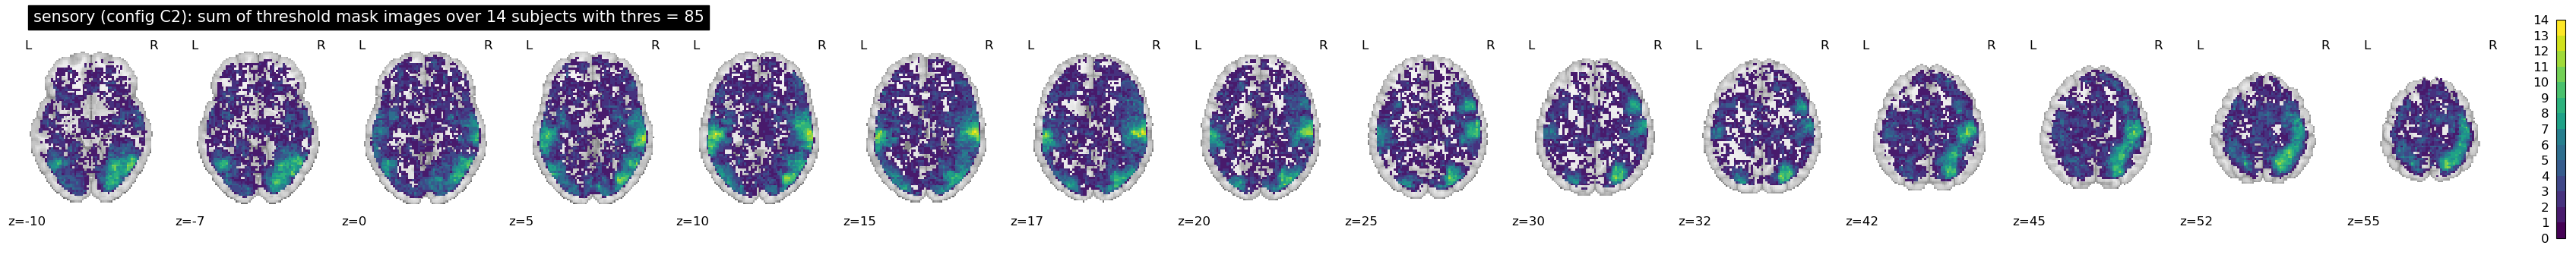

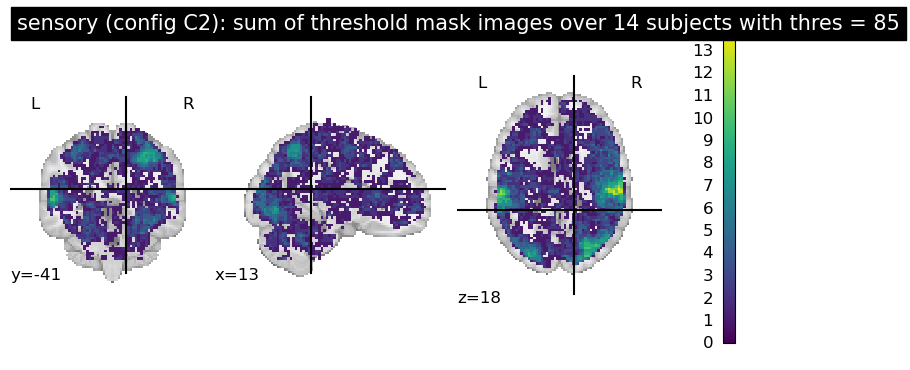

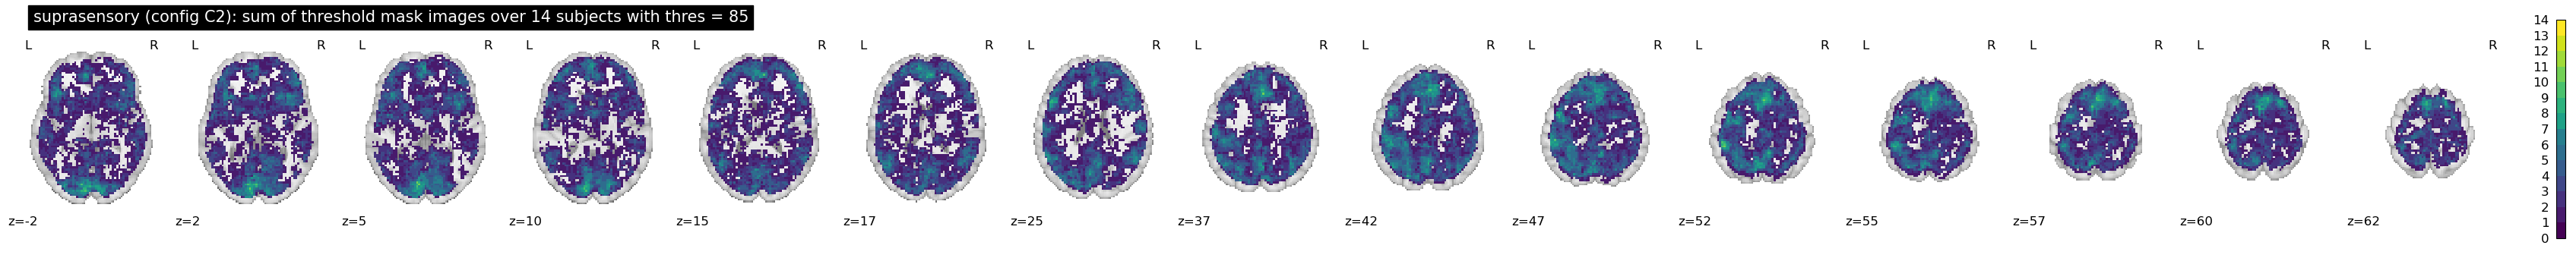

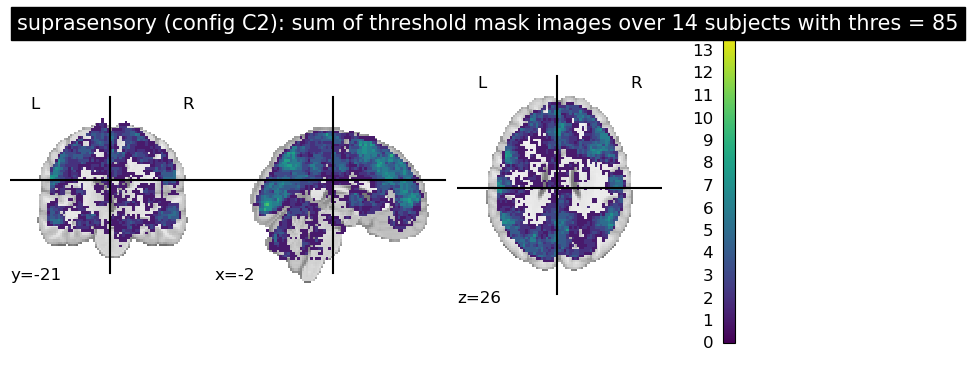

In [13]:
MRI_subjects = get_MRI_subjects()
all_subjects = [subj for subj in MRI_subjects if '19970218crpo' not in subj]

thres = 85

plot_mean(all_subjects, 'MRIconfig_C2', 'sensory', thres=thres, save = False)
plot_mean(all_subjects, 'MRIconfig_C2', 'sensory', thres=thres, save = False, plotList=[2])

plot_mean(all_subjects, 'MRIconfig_C2', 'suprasensory', thres=thres, save = False)
plot_mean(all_subjects, 'MRIconfig_C2', 'suprasensory', thres=thres, save = False, plotList=[2])


Removed bad subject: 19970218crpo

all MRI subjects: ['20010917rswg', '19960630cahi', '19970302urmr', '19840930bigs', '20040627vrrj', '19880331igse', '20020123sbhp', '20020705ttbr', '19961123crsh', '19951227eipo', '19921205crfi', '19991211mrbn', '19910823ssld', '19910703eigl']


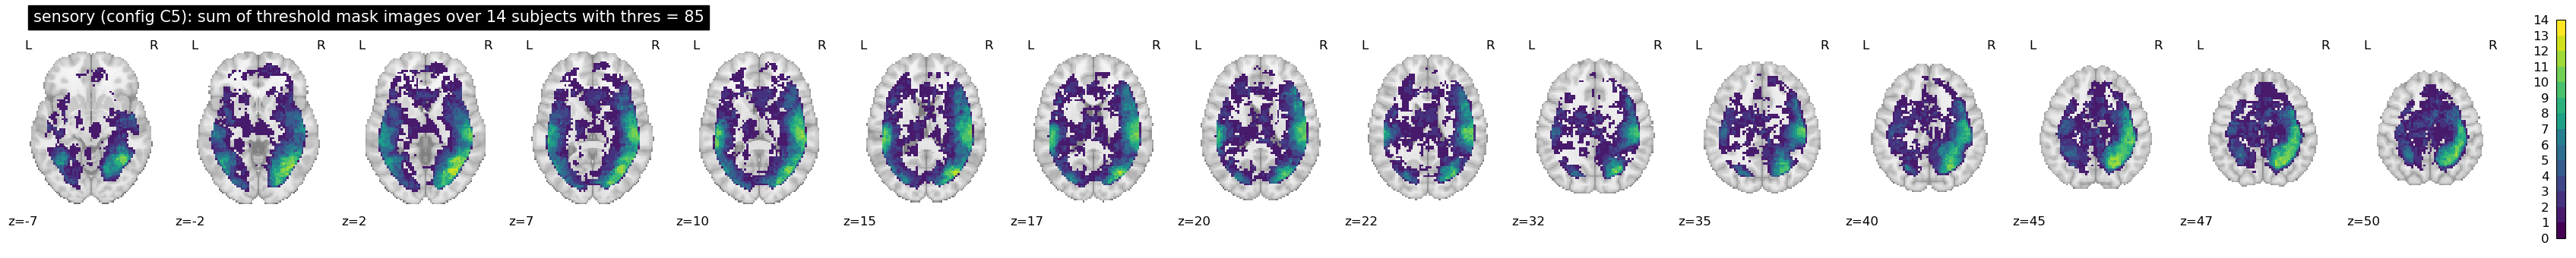

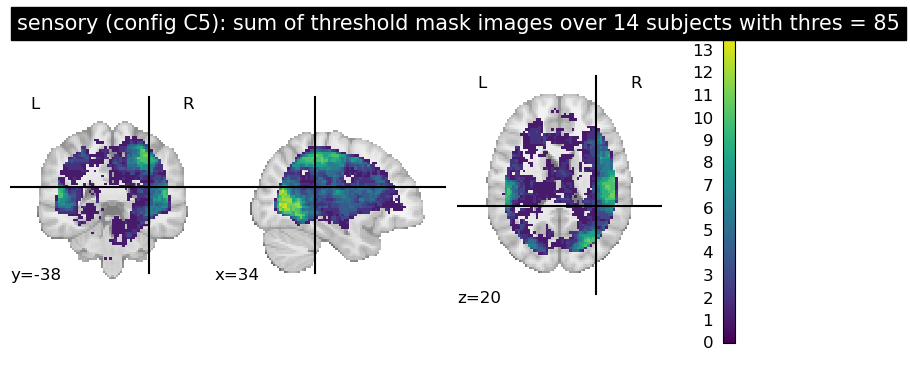

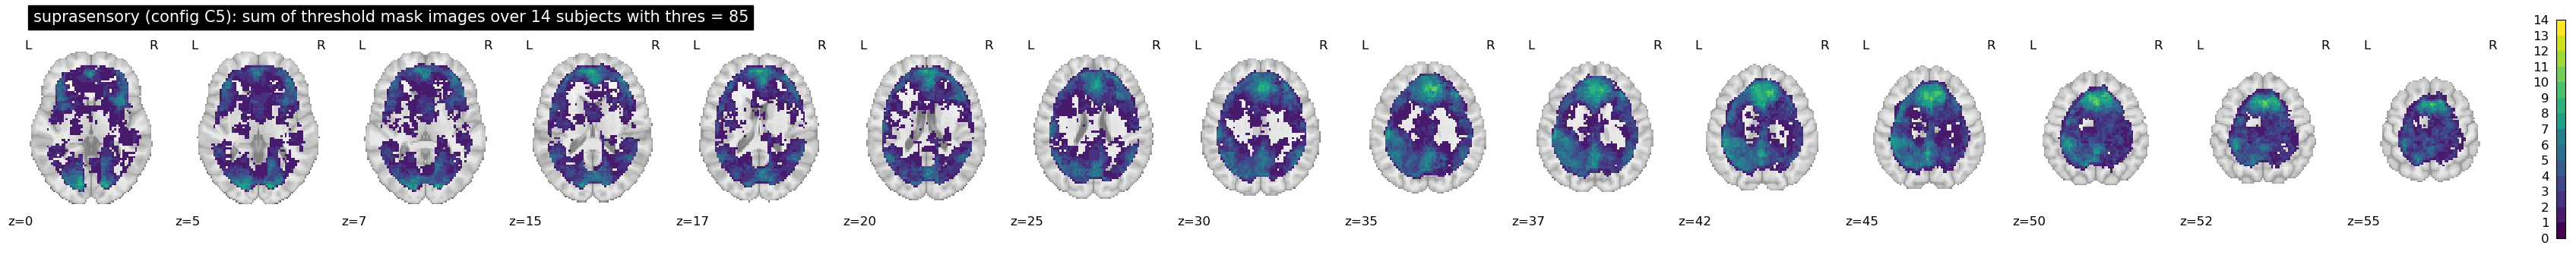

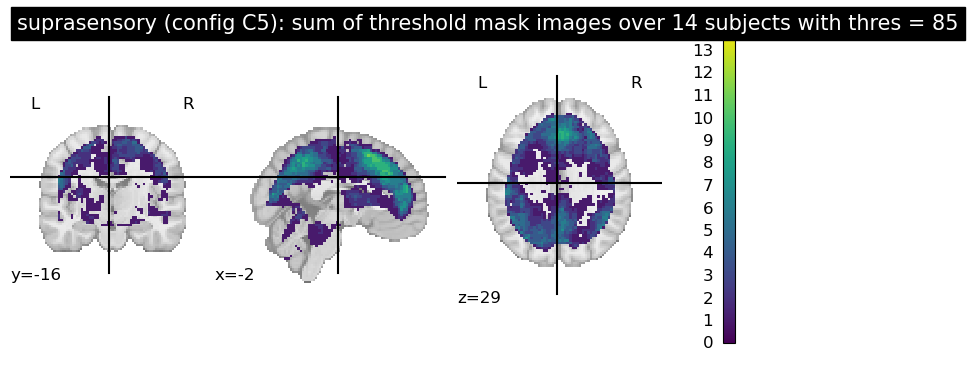

In [14]:
MRI_subjects = get_MRI_subjects()
all_subjects = [subj for subj in MRI_subjects if '19970218crpo' not in subj]
thres=85
plot_mean(all_subjects, 'MRIconfig_C5', 'sensory', thres=thres, save = False)
plot_mean(all_subjects, 'MRIconfig_C5', 'sensory', thres=thres, save = False, plotList=[2])

plot_mean(all_subjects, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False)
plot_mean(all_subjects, 'MRIconfig_C5', 'suprasensory', thres=thres, save = False, plotList=[2])


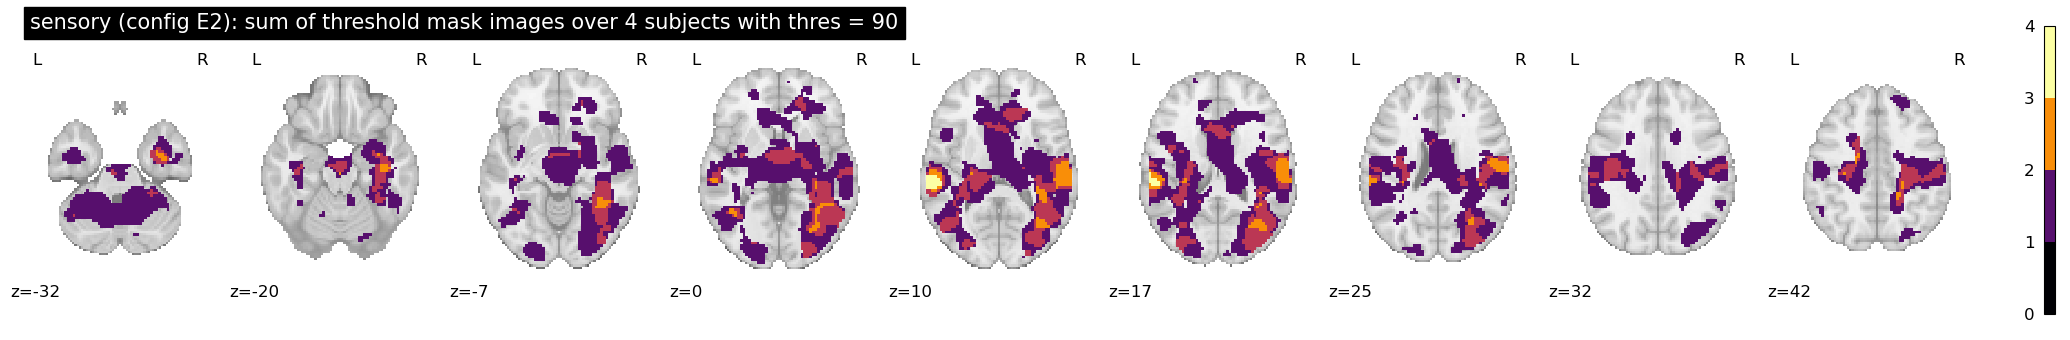

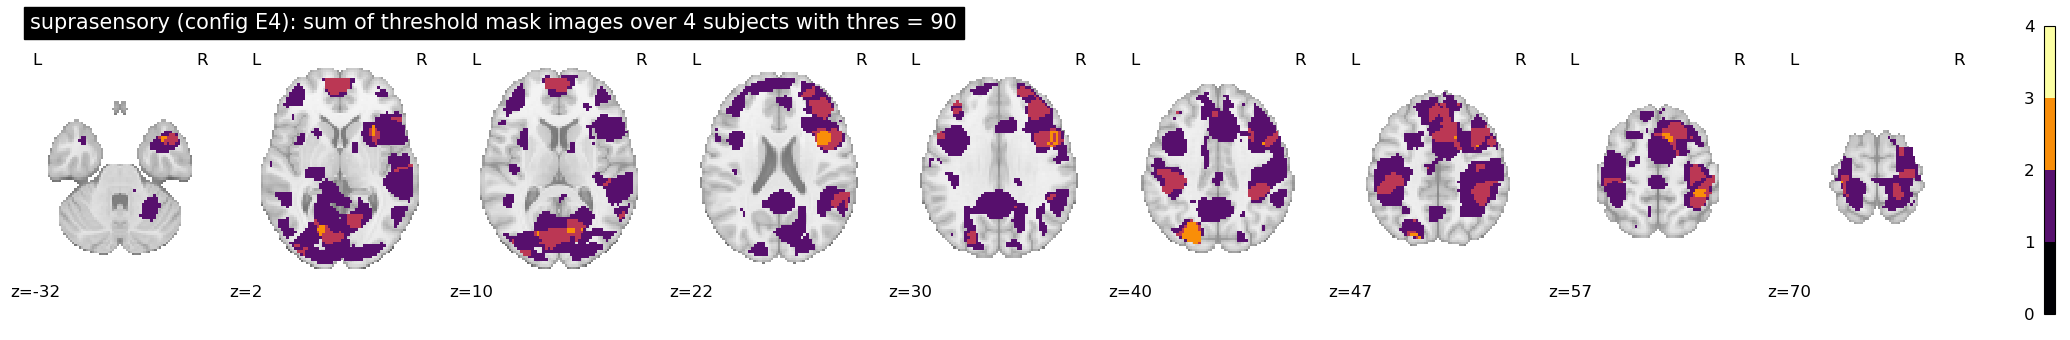

In [ ]:
# --> threshold: 90%

all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=90)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=90)

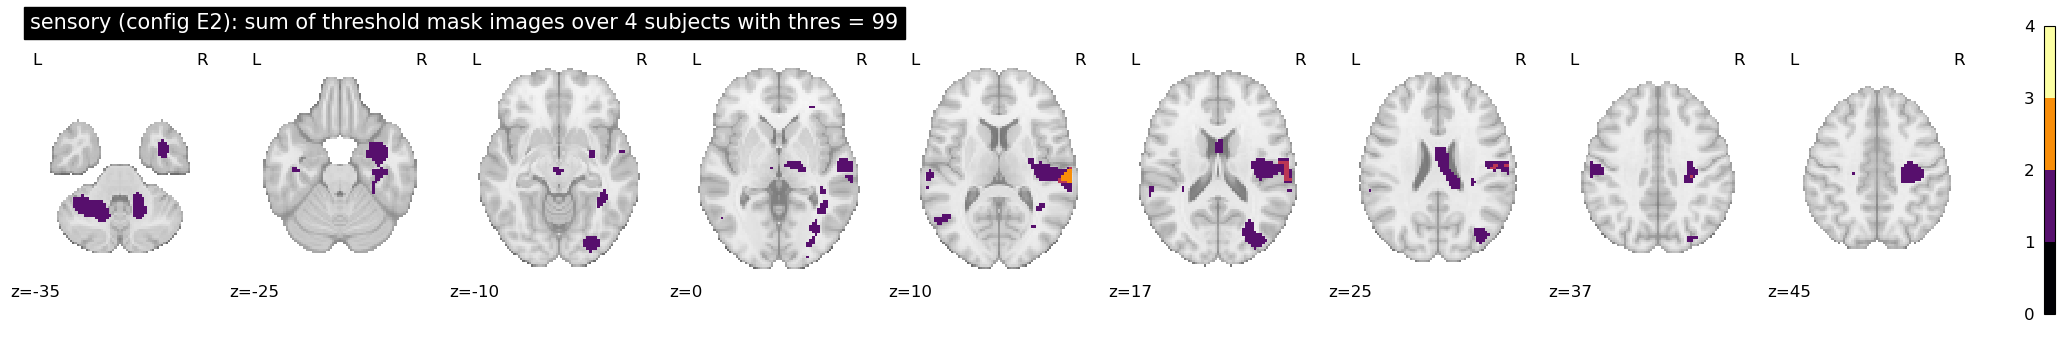

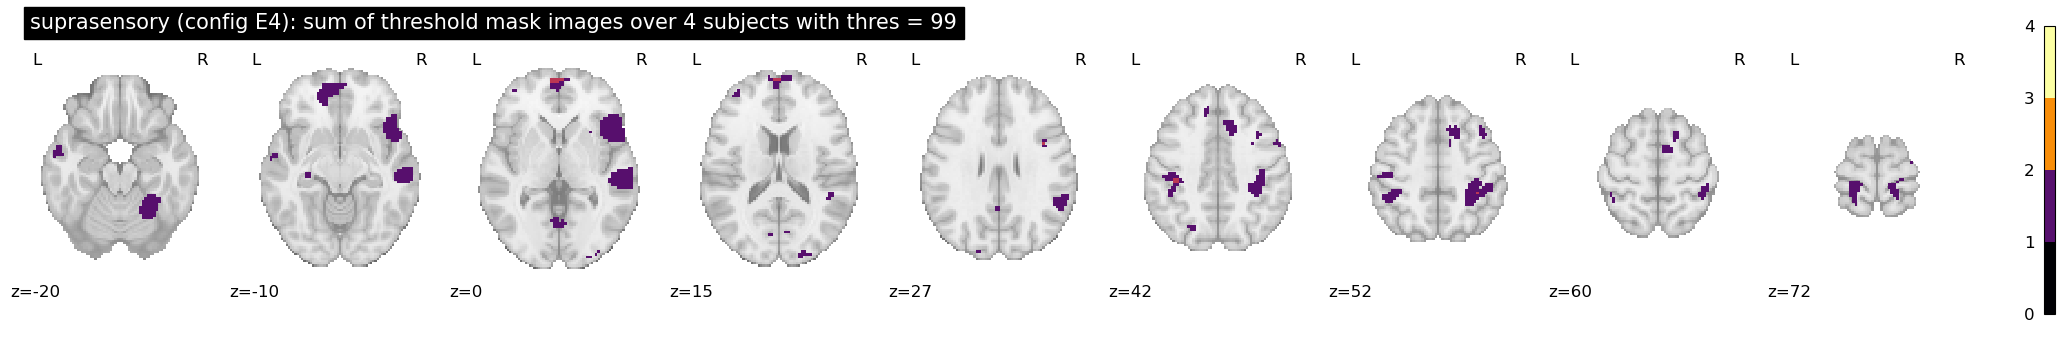

In [ ]:
# --> threshold: 99%

all_subjects = ["19910823ssld", "19970302urmr", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=99)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=99)

## 6 subjects


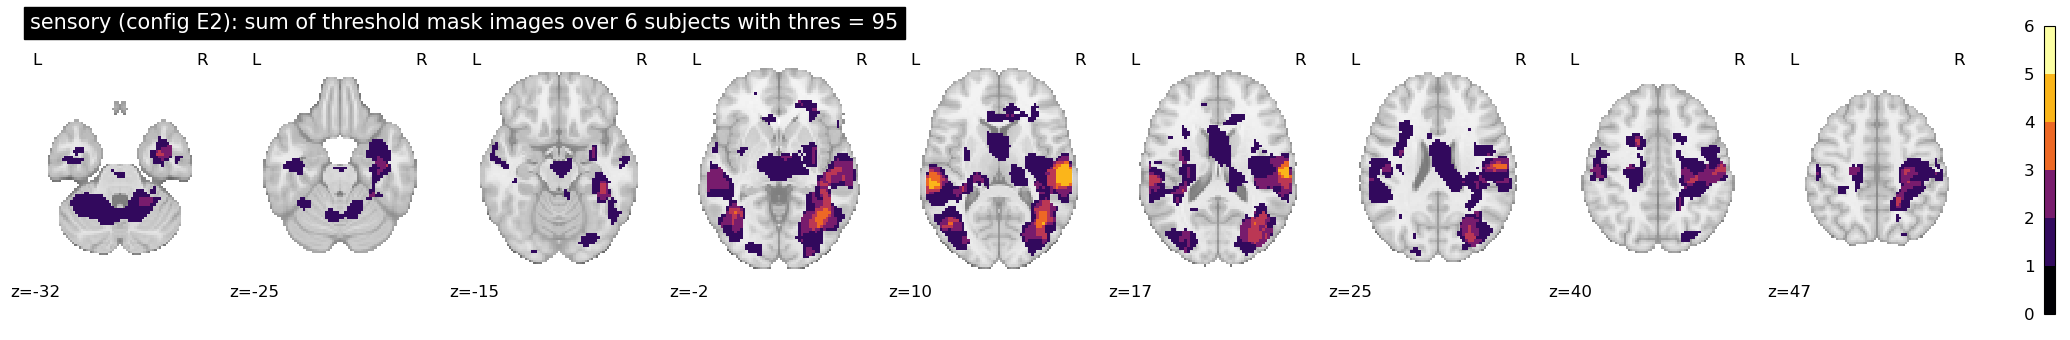

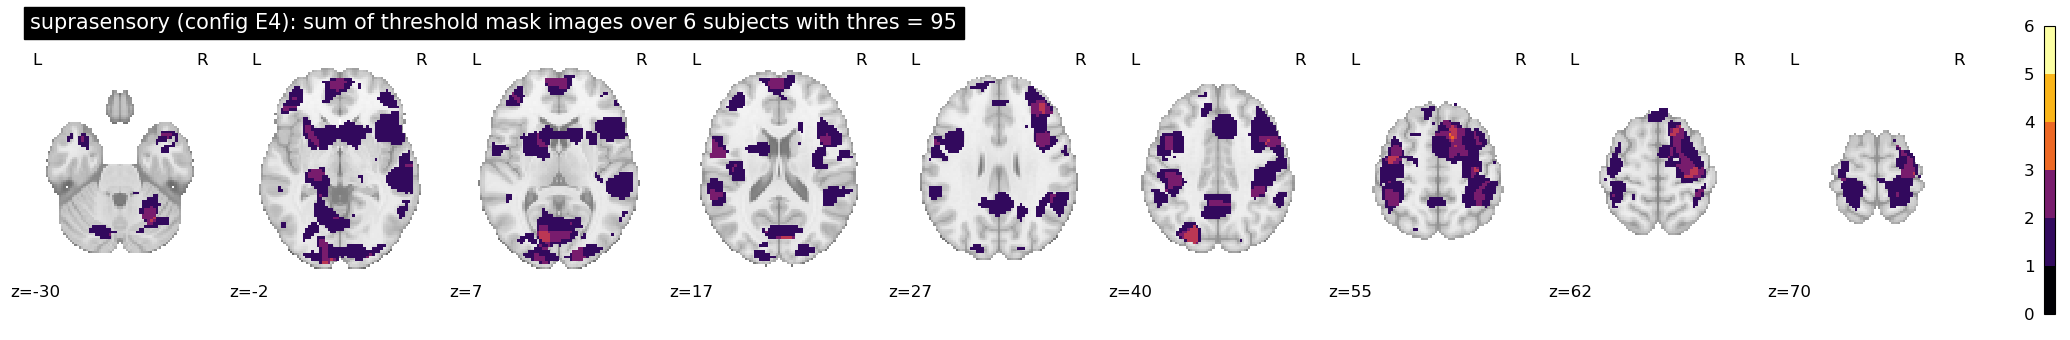

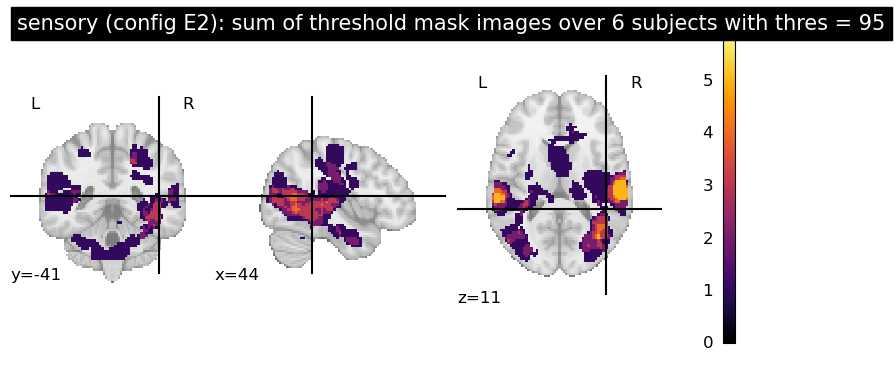

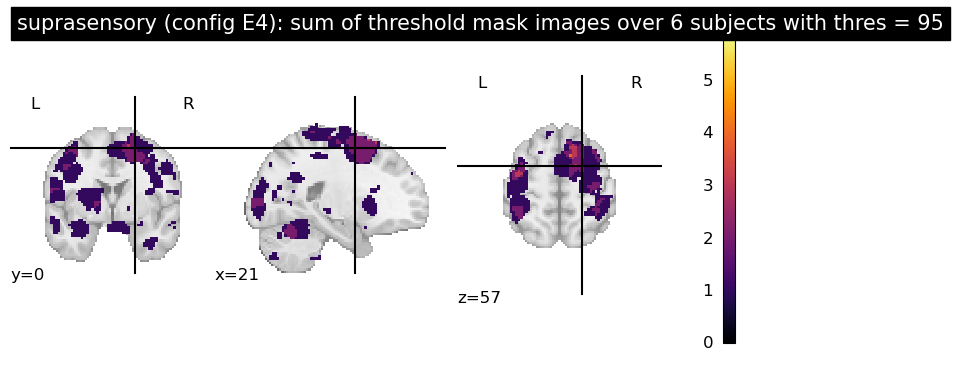

In [26]:
# --> threshold: 95%

all_subjects = ["19910823ssld", "19951227eipo", "19970302urmr", "20020123sbhp", "20020705ttbr", "19991211mrbn"]

config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, save = True)

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, save = True)


config_class_name = 'SensoryConfig_E2'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])

config_class_name = 'SensoryConfig_E4'
plot_mean(all_subjects, config_class_name, thres=95, plotList=[2])